In [21]:
%load_ext autoreload
%autoreload 2

'''
Importing the modules
'''
import config_2D_coupling_V2 as cfg         # config = physical & simulation parameters 
from solver_2D_coupling_V2 import *         # solver = FEM method + pmls
import post_process_2D_coupling_V2 as my_pp # post_process = plotting functions
from ngsolve import exp 
import numpy as np  


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from ngsolve import exp, IfPos
from scipy.interpolate import PchipInterpolator

def create_density_profile(x_sym, z_sym):
    '''
    Define a 2D (x,z) arbitrary profile of density n_e(x,z).
    Upgraded with PCHIP spline for C1 continuity to prevent FEM reflections.
    '''
    # TYPE: str
    prof_type = cfg.PLASMA.get('profile_type', 'exponential')
    if prof_type == 'contant':
        return cfg.PLASMA['ne_constant']
    elif prof_type == 'exponential':
        # TYPE: float
        Lx_plasma = cfg.DOMAIN['Lx_plasma']
        n_edge = cfg.PLASMA['lin_prof_n'][0]
        n_core = cfg.PLASMA['lin_prof_n'][-1]

        # TYPE: float
        lambda_val = np.log(n_core / n_edge) / Lx_plasma
        
        # TYPE: ngsolve.CoefficientFunction
        n_e_profile = n_edge * exp(lambda_val * x_sym)
        return n_e_profile

    elif prof_type == 'piecewise_linear':
        # Convert points to numpy arrays
        # TYPE: np.ndarray, SHAPE: (N,)
        x_pts = np.array(cfg.PLASMA['lin_prof_x'])
        n_pts = np.array(cfg.PLASMA['lin_prof_n'])

        # Compute Hermite Spline coefficients to ensure smooth monotonic transitions
        # TYPE: scipy.interpolate.PchipInterpolator
        spline = PchipInterpolator(x_pts, n_pts)

        # TYPE: float | ngsolve.CoefficientFunction
        n_e_profile = 0.0

        for i in range(len(x_pts) - 1):
            # TYPE: float
            x0, x1 = x_pts[i], x_pts[i+1]

            # Extract cubic polynomial coefficients for segment i
            # TYPE: float
            c3, c2, c1, c0 = spline.c[:, i]

            # TYPE: ngsolve.CoefficientFunction
            dx = x_sym - x0
            poly = c3*dx**3 + c2*dx**2 + c1*dx + c0

            # Masking to apply polynomial only on the local segment
            # TYPE: ngsolve.CoefficientFunction
            if i == len(x_pts) - 2:
                mask = IfPos(x_sym - x0, 1.0, 0.0)
            else:
                mask = IfPos(x_sym - x0, 1.0, 0.0) - IfPos(x_sym - x1, 1.0, 0.0)

            n_e_profile = n_e_profile + mask * poly

        return n_e_profile
    else:
        raise ValueError("Profile type not supported. Use 'exponential' or 'piecewise_linear'.")

In [23]:
# 1. Solver initialization
solver = LHCouplingSolver(cfg.__dict__)
solver.build_mesh()

# 2. Physics implementation + solving system
print("--- Introducing n_e profile in General Stix Tensor ---")
solver.build_physics(lambda x_sym, z_sym: create_density_profile(x_sym, z_sym))
solver.solve_system()

[CHECKPOINT] Degrees of freedom: 362103
--- Introducing n_e profile in General Stix Tensor ---
--- Système solved ---


--- Post-Processing ---

[SYSTEM] Dossier de sauvegarde créé : Simulation_Results/Run_20260409_151727
run_folder Simulation_Results/Run_20260409_151727
[SYSTEM] Configuration sauvegardée dans : Simulation_Results/Run_20260409_151727/simulation_parameters.json
sim_target_folder:  /home/remi/Perso/Stage/M2_IRFM/Codes/LH_2D_Coupling/Simulation_Results/Run_20260409_151727
--- 2D map generation of (norm) ---
Max norm amplitude detected in grid: 3.8026e+02 V/m


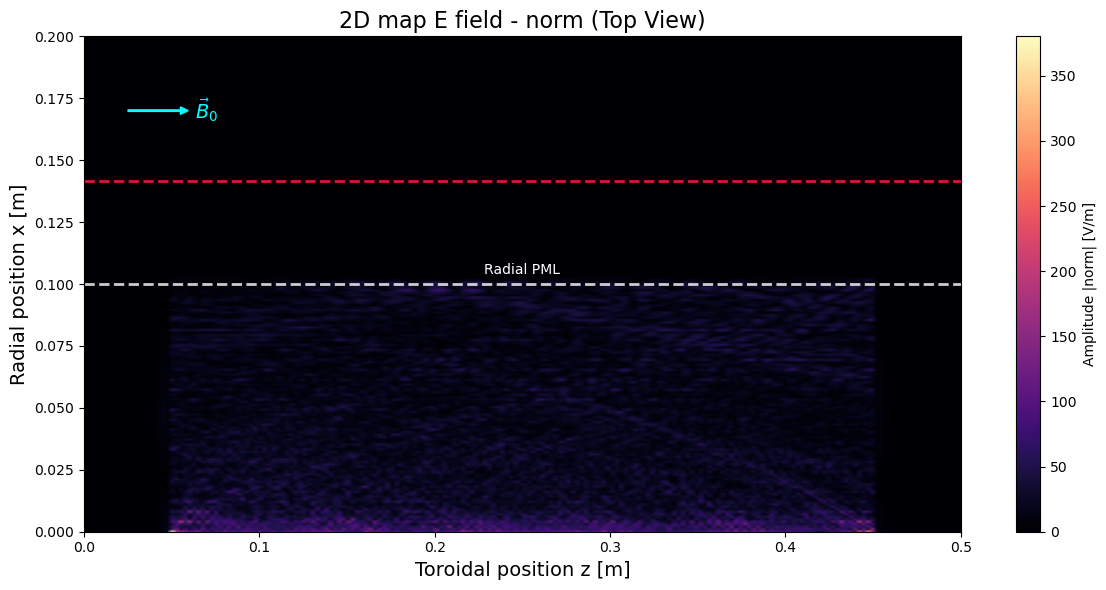

--- Extraction et moyennage toroïdal des profils radiaux ---


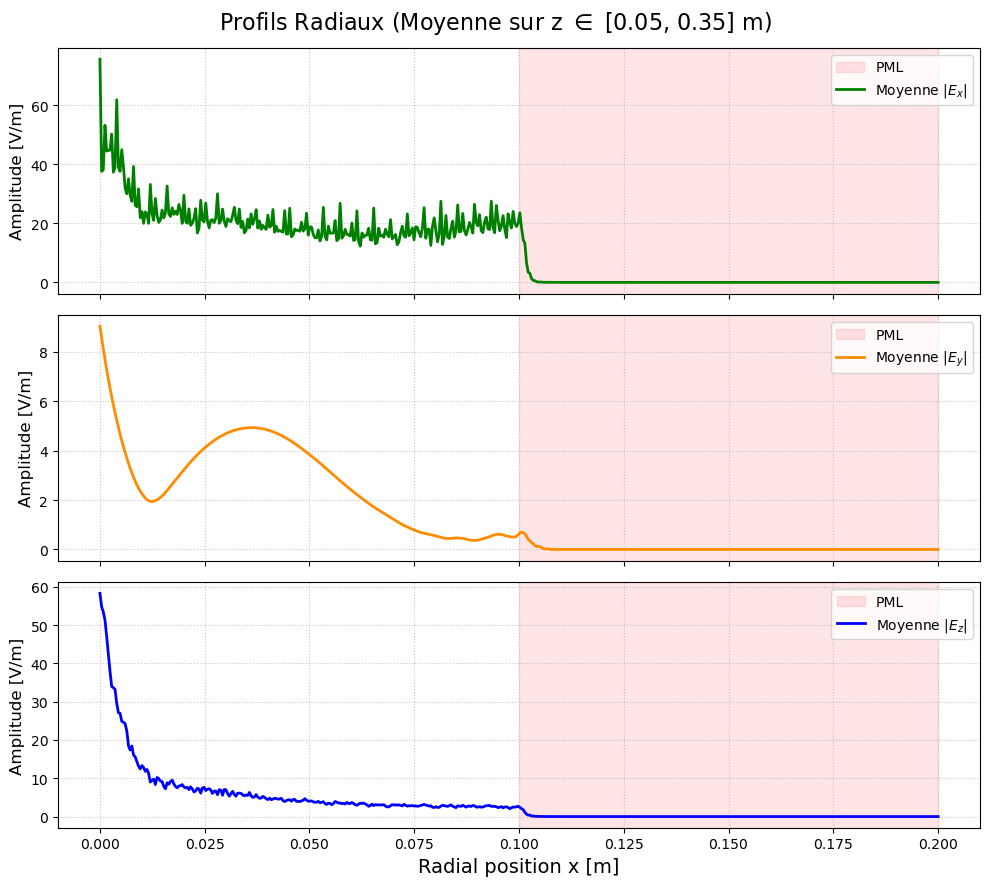

--- 2D & 1D map generation of (Electron Density n_e) ---
map density piecewise_linear


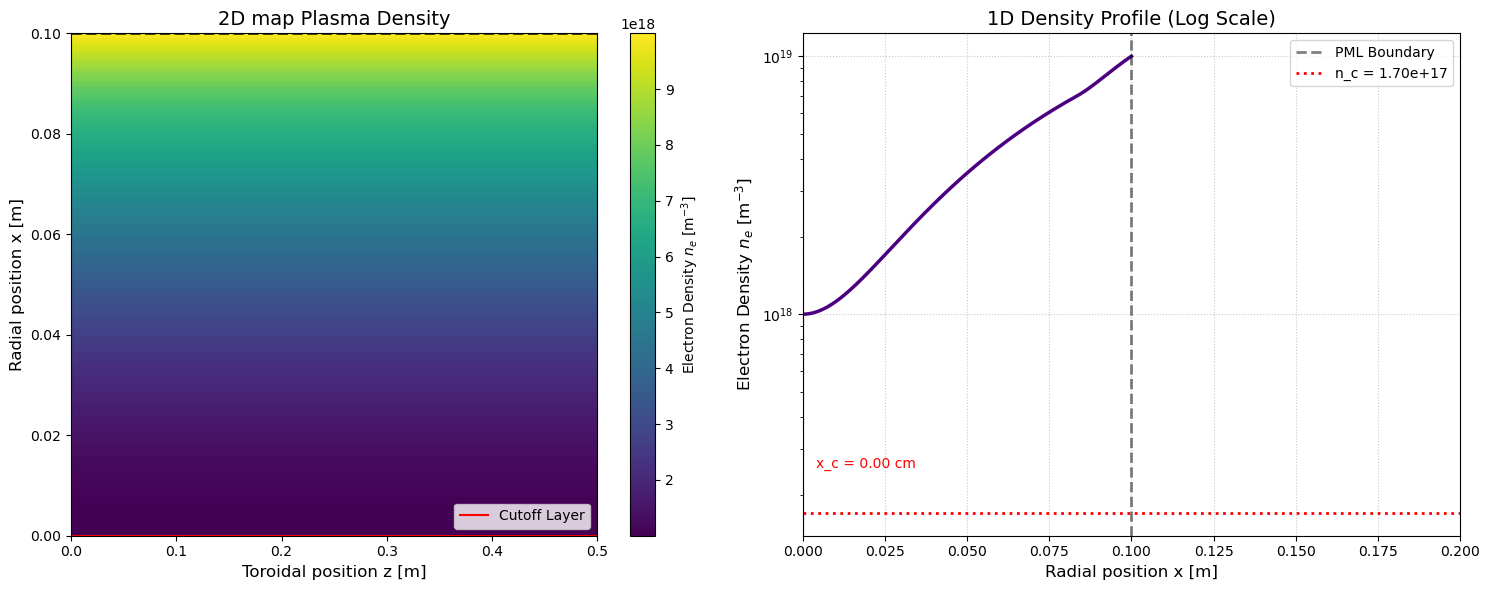

--- 2D map generation of (Magnetic Field B_tot + Vectors) ---


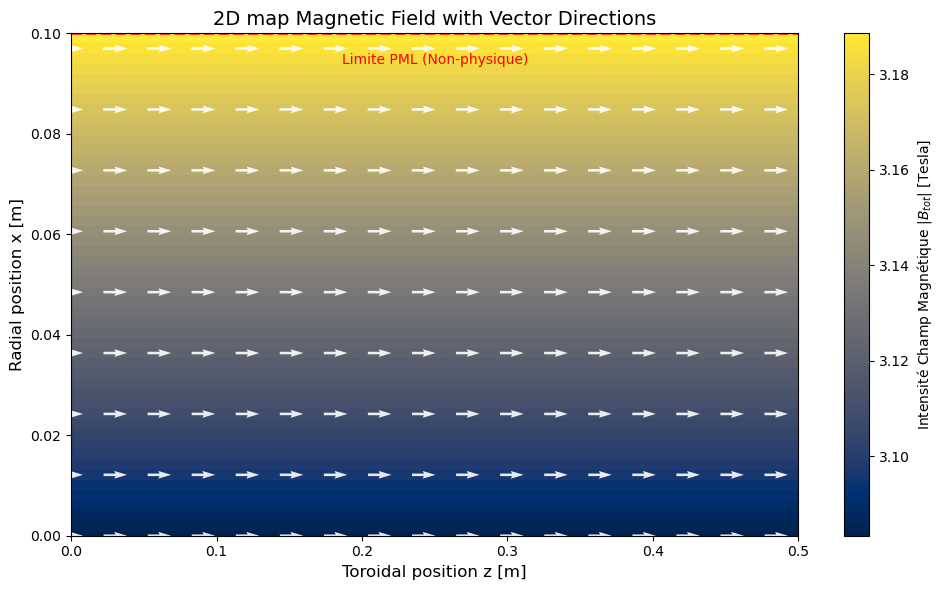

In [24]:
# 3. Post processing
print("--- Post-Processing ---")


run_folder = my_pp.setup_output_directory("Simulation_Results")
print('run_folder', run_folder)
my_pp.save_configuration(cfg.__dict__, run_folder)

sim_target_folder = "/home/remi/Perso/Stage/M2_IRFM/Codes/LH_2D_Coupling/" + run_folder
print('sim_target_folder: ', sim_target_folder)

my_pp.plot_2d_map(solver, sim_target_folder, component ='norm', resolution=200)
z_mid = cfg.DOMAIN['Lz_plasma'] / 2.0
# my_pp.plot_radial_components(solver, z_target=z_mid)
my_pp.plot_radial_components_averaged(solver, sim_target_folder)

my_pp.plot_density_profile_2d(solver, sim_target_folder)
my_pp.plot_b_field_2d(solver, sim_target_folder)
